In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('All imports loaded successfully!')


All imports loaded successfully!


### Load and explore Telco Customer Churn Dataset

In [2]:
# Load dataset
df_raw = pd.read_csv('../data/Telco-Customer-Churn.csv')

print(f'Dataset shape: {df_raw.shape}')
print(f'Columns: {df_raw.shape[1]}')
for i, col in enumerate(df_raw.columns):
    print(f'  {i+1:2d}. {col} ({df_raw[col].dtype})')
print(f'\nFirst 3 rows:')
df_raw.head(3)

Dataset shape: (7043, 21)
Columns: 21
   1. customerID (str)
   2. gender (str)
   3. SeniorCitizen (int64)
   4. Partner (str)
   5. Dependents (str)
   6. tenure (int64)
   7. PhoneService (str)
   8. MultipleLines (str)
   9. InternetService (str)
  10. OnlineSecurity (str)
  11. OnlineBackup (str)
  12. DeviceProtection (str)
  13. TechSupport (str)
  14. StreamingTV (str)
  15. StreamingMovies (str)
  16. Contract (str)
  17. PaperlessBilling (str)
  18. PaymentMethod (str)
  19. MonthlyCharges (float64)
  20. TotalCharges (str)
  21. Churn (str)

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# Dataset overview — types, nulls, hidden issues
print('='*65)
print('DATASET OVERVIEW')
print('='*65)

print(f'\nShape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'\nTarget distribution:')
print(df_raw['Churn'].value_counts())
print(f'Churn rate: {(df_raw["Churn"] == "Yes").mean():.1%}')

print(f'\n--- Column Types ---')
print(df_raw.dtypes.value_counts())

print(f'\n--- Missing Values ---')
print(f'Explicit NaN count: {df_raw.isnull().sum().sum()}')

# TotalCharges has hidden missing values — empty strings, not NaN!
print(f'TotalCharges empty strings: {(df_raw["TotalCharges"] == " ").sum()}')


DATASET OVERVIEW

Shape: 7,043 rows x 21 columns

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.5%

--- Column Types ---
str        18
int64       2
float64     1
Name: count, dtype: int64

--- Missing Values ---
Explicit NaN count: 0
TotalCharges empty strings: 11


#### Observation: 
TotalCharges has empty strings masquerading as valid data. pandas read it as object (string) type instead of float.

#### Data Cleaning & Feature Engineering

In [4]:
# Data Cleaning cleaning and preprocessing

df = df_raw.copy()

# 1. Drop CustomerID (not a feature - it's a row identifier)
df = df.drop('customerID', axis=1)

# 2. Fix TotalCharges: empty strings -> NaN -> fill with 0.0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_missing = df['TotalCharges'].isna().sum()
missing_tenure = df.loc[df['TotalCharges'].isna(), 'tenure'].unique()
print(f'TotalCharges NaN after conversion: {n_missing}')
print(f'  Their tenure values: {missing_tenure}')
print(f'  -> Filling with 0.0 (new customers, no charges yet)')
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# 3. Encode target: Yes=1, No=0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# 4. Identify column types for encoding strategy
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print(f'\nColumn breakdown:')
print(f'  Binary (Yes/No):     {len(binary_cols)} cols -> label encode (0/1)')
print(f'  Multi-category:      {len(multi_cat_cols)} cols -> one-hot encode')
print(f'  Numeric:             {len(numeric_cols)} cols -> keep as-is')
print(f'  Already binary int:  SeniorCitizen')

TotalCharges NaN after conversion: 11
  Their tenure values: [0]
  -> Filling with 0.0 (new customers, no charges yet)

Column breakdown:
  Binary (Yes/No):     5 cols -> label encode (0/1)
  Multi-category:      10 cols -> one-hot encode
  Numeric:             3 cols -> keep as-is
  Already binary int:  SeniorCitizen


In [5]:
# Encode categorical features

# TWO encoding strategies:
#   Binary (Yes/No)    -> Label encode (0/1) — safe because only 2 values
#   Multi-category     -> One-hot encode — necessary to avoid imposing false ordering

# Binary encoding (Yes=1, No=0)
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in binary_cols:
    df[col] = df[col].map(binary_map)

# One-hot encoding (drop_first=True to avoid multicollinearity)
df_encoded = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True, dtype=int)

print(f'Shape before encoding: {df.shape}')
print(f'Shape after encoding:  {df_encoded.shape}')
print(f'\nNew one-hot columns created:')
new_cols = [c for c in df_encoded.columns if c not in df.columns]
for c in new_cols:
    print(f'  {c}')
print(f'\nTotal features for model: {df_encoded.shape[1] - 1} (excluding target)')

Shape before encoding: (7043, 20)
Shape after encoding:  (7043, 31)

New one-hot columns created:
  MultipleLines_No phone service
  MultipleLines_Yes
  InternetService_Fiber optic
  InternetService_No
  OnlineSecurity_No internet service
  OnlineSecurity_Yes
  OnlineBackup_No internet service
  OnlineBackup_Yes
  DeviceProtection_No internet service
  DeviceProtection_Yes
  TechSupport_No internet service
  TechSupport_Yes
  StreamingTV_No internet service
  StreamingTV_Yes
  StreamingMovies_No internet service
  StreamingMovies_Yes
  Contract_One year
  Contract_Two year
  PaymentMethod_Credit card (automatic)
  PaymentMethod_Electronic check
  PaymentMethod_Mailed check

Total features for model: 30 (excluding target)


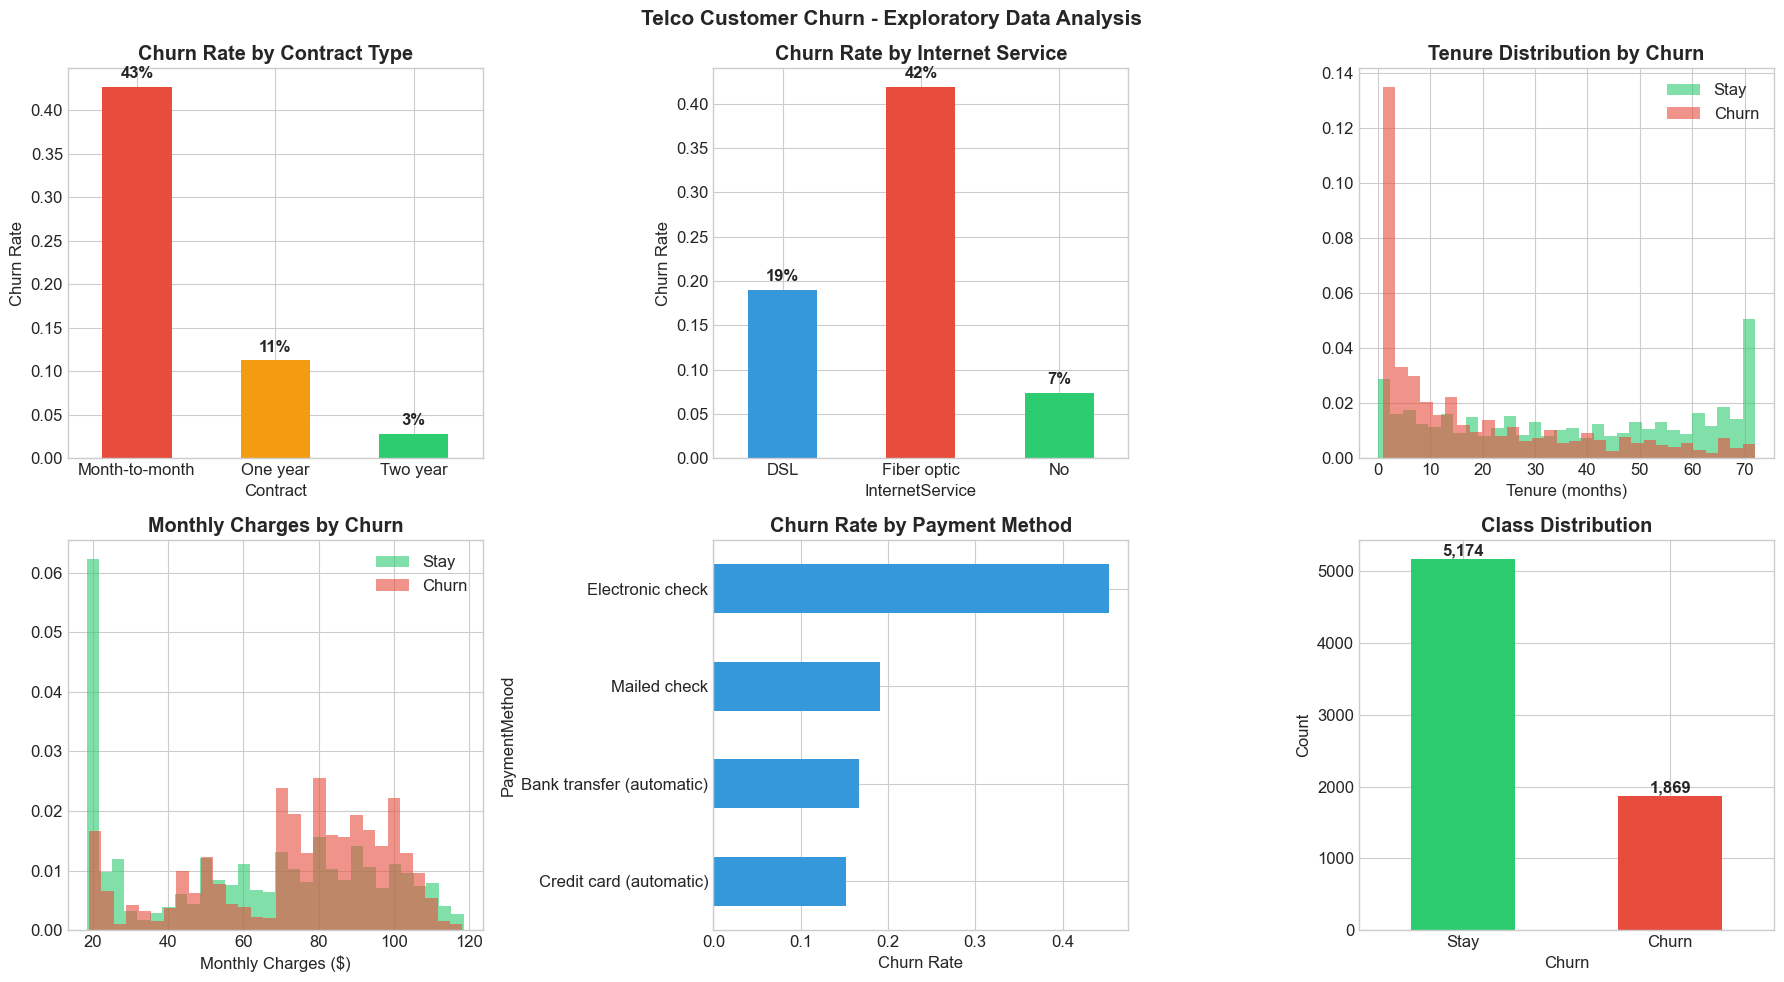

Key Observations:
  1. Month-to-month contracts have ~42% churn vs ~3% for two-year
  2. Fiber optic customers churn more (~42%) — possibly price/quality issues
  3. New customers (low tenure) churn the most
  4. Higher monthly charges correlate with more churn
  5. Electronic check users churn the most (~45%)


In [6]:
# EDA - Churn rate by key features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Churn by Contract type
ax = axes[0, 0]
contract_churn = df_raw.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean())
contract_churn = contract_churn.reindex(['Month-to-month', 'One year', 'Two year'])
contract_churn.plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('Churn Rate by Contract Type', fontweight='bold')
ax.set_ylabel('Churn Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(contract_churn):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontweight='bold')

# 2. Churn by Internet Service
ax = axes[0, 1]
internet_churn = df_raw.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean())
internet_churn.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_title('Churn Rate by Internet Service', fontweight='bold')
ax.set_ylabel('Churn Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(internet_churn):
    ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontweight='bold')

# 3. Tenure distribution by churn
ax = axes[0, 2]
ax.hist(df_raw[df_raw['Churn']=='No']['tenure'], bins=30, alpha=0.6,
        label='Stay', color='#2ecc71', density=True)
ax.hist(df_raw[df_raw['Churn']=='Yes']['tenure'], bins=30, alpha=0.6,
        label='Churn', color='#e74c3c', density=True)
ax.set_title('Tenure Distribution by Churn', fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.legend()

# 4. Monthly charges by churn
ax = axes[1, 0]
ax.hist(df_raw[df_raw['Churn']=='No']['MonthlyCharges'], bins=30, alpha=0.6,
        label='Stay', color='#2ecc71', density=True)
ax.hist(df_raw[df_raw['Churn']=='Yes']['MonthlyCharges'], bins=30, alpha=0.6,
        label='Churn', color='#e74c3c', density=True)
ax.set_title('Monthly Charges by Churn', fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.legend()

# 5. Payment method
ax = axes[1, 1]
pay_churn = df_raw.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x=='Yes').mean()).sort_values()
pay_churn.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Churn Rate by Payment Method', fontweight='bold')
ax.set_xlabel('Churn Rate')

# 6. Class balance
ax = axes[1, 2]
counts = df_raw['Churn'].value_counts()
counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.set_xticklabels(['Stay', 'Churn'], rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Telco Customer Churn - Exploratory Data Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualisations/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key Observations:')
print('  1. Month-to-month contracts have ~42% churn vs ~3% for two-year')
print('  2. Fiber optic customers churn more (~42%) — possibly price/quality issues')
print('  3. New customers (low tenure) churn the most')
print('  4. Higher monthly charges correlate with more churn')
print('  5. Electronic check users churn the most (~45%)')

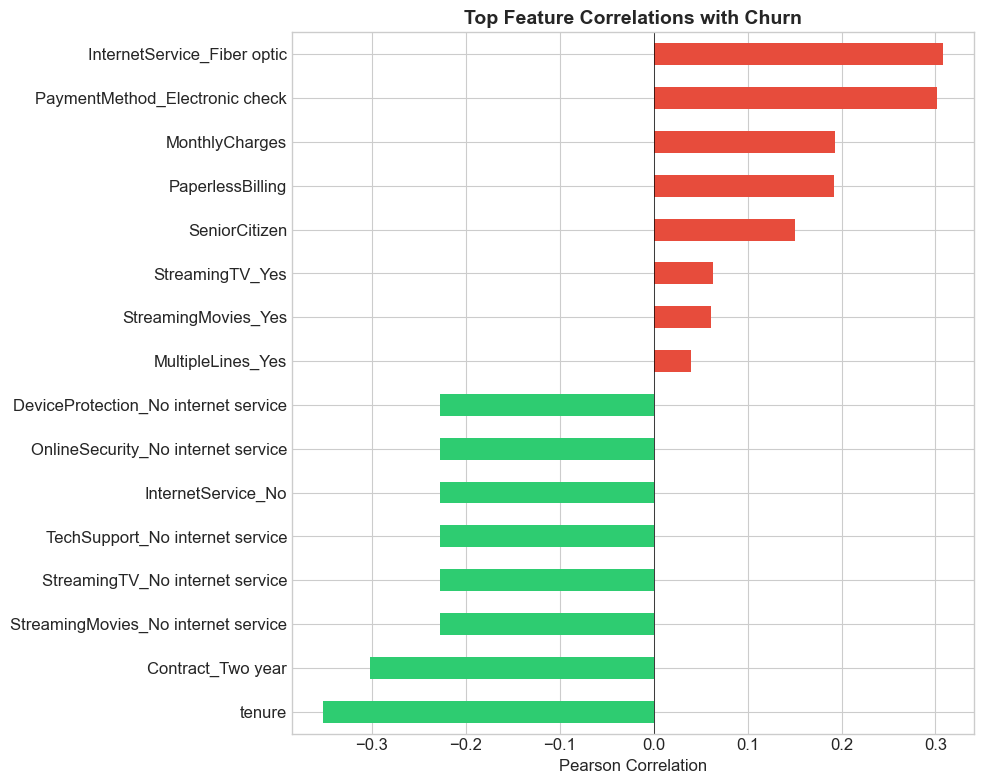

Strongest churn predictors:
  INCREASES churn: Month-to-month contract, Fiber optic, Electronic check
  DECREASES churn: Long tenure, Two-year contract, TotalCharges (loyal customers)


In [7]:
# Top feature correlations with churn
fig, ax = plt.subplots(figsize=(10, 8))

churn_corr = df_encoded.corr()['Churn'].drop('Churn').sort_values()
top_features = pd.concat([churn_corr.head(8), churn_corr.tail(8)])
colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in top_features]
top_features.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top Feature Correlations with Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../visualisations/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Strongest churn predictors:')
print('  INCREASES churn: Month-to-month contract, Fiber optic, Electronic check')
print('  DECREASES churn: Long tenure, Two-year contract, TotalCharges (loyal customers)')

#### Logisitic Regression Implementation

In [8]:
# Logistic Regression implementation

class LogisticRegressionScratch:
    """
    Logistic Regression binary classifier using gradient descent.
    Supports optional L2 (Ridge) regularization.

    Parameters
    ----------
    learning_rate : float
        Step size for gradient descent (default: 0.01)
    n_iterations : int
        Number of gradient descent steps (default: 1000)
    lambda_reg : float
        L2 regularization strength (default: 0.0 = no regularization)
    threshold : float
        Classification threshold (default: 0.5)
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000,
                 lambda_reg=0.0, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.lambda_reg = lambda_reg
        self.threshold = threshold
        self.weights = None
        self.bias = None
        self.cost_history = []

    def _sigmoid(self, z):
        """Numerically stable sigmoid."""
        return np.where(
            z >= 0,
            1 / (1 + np.exp(-z)),
            np.exp(z) / (1 + np.exp(z))
        )

    def _compute_cost(self, y, y_pred):
        """
        Binary cross-entropy loss with optional L2 regularization.

        J(theta) = -(1/m) * sum[y*log(y_hat) + (1-y)*log(1-y_hat)] + (lambda/2m)*sum(w^2)
        """
        m = len(y)
        eps = 1e-15  # Prevent log(0)
        y_pred = np.clip(y_pred, eps, 1 - eps)

        # Cross-entropy
        ce_loss = -(1/m) * np.sum(
            y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred)
        )

        # L2 regularization (don't regularize bias)
        l2_term = (self.lambda_reg / (2 * m)) * np.sum(self.weights ** 2)

        return ce_loss + l2_term

    def fit(self, X, y):
        """
        Train the model using gradient descent.

        Parameters
        ----------
        X : np.ndarray, shape (m, n) - Training features (should be scaled)
        y : np.ndarray, shape (m,) - Binary labels (0 or 1)
        """
        m, n = X.shape

        # Initialize weights to zeros
        self.weights = np.zeros(n)
        self.bias = 0.0
        self.cost_history = []

        for i in range(self.n_iterations):
            # Forward pass: z = Xw + b, then sigmoid
            z = X @ self.weights + self.bias
            y_pred = self._sigmoid(z)

            # Compute gradients
            eps = 1e-15
            y_pred_safe = np.clip(y_pred, eps, 1 - eps)
            error = y_pred_safe - y
            dw = (1/m) * (X.T @ error) + (self.lambda_reg / m) * self.weights
            db = (1/m) * np.sum(error)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Track cost every 100 iterations
            if i % 100 == 0:
                cost = self._compute_cost(y, y_pred_safe)
                self.cost_history.append(cost)

        return self

    def predict_proba(self, X):
        """Return probability of class 1 (churn)."""
        z = X @ self.weights + self.bias
        return self._sigmoid(z)

    def predict(self, X):
        """Return binary predictions using threshold."""
        return (self.predict_proba(X) >= self.threshold).astype(int)

print('LogisticRegressionScratch class defined!')
print('Methods: fit(), predict(), predict_proba()')

LogisticRegressionScratch class defined!
Methods: fit(), predict(), predict_proba()


In [9]:
# Prepare features for training
feature_cols = [c for c in df_encoded.columns if c != 'Churn']
X = df_encoded[feature_cols].values
y = df_encoded['Churn'].values

print(f'Features: {len(feature_cols)}')
print(f'Samples:  {len(y):,}')
print(f'Churn rate: {y.mean():.1%}')

# Train-test split (80/20, stratified to preserve churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]:,} samples (churn: {y_train.mean():.1%})')
print(f'Test:  {X_test.shape[0]:,} samples (churn: {y_test.mean():.1%})')

# Feature scaling - CRITICAL for gradient descent convergence
# Scales all features to mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use TRAIN statistics!

print(f'\nStandardScaler applied to all {len(feature_cols)} features')

Features: 30
Samples:  7,043
Churn rate: 26.5%

Train: 5,634 samples (churn: 26.5%)
Test:  1,409 samples (churn: 26.5%)

StandardScaler applied to all 30 features


In [10]:
# Train our scratch model
print('Training Logistic Regression from Scratch...')
print('='*55)

model = LogisticRegressionScratch(
    learning_rate=0.1,
    n_iterations=5000,
    lambda_reg=0.01
)

model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

print(f'\n--- Training Metrics ---')
print(f'Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}')
print(f'Precision: {precision_score(y_train, y_train_pred):.4f}')
print(f'Recall:    {recall_score(y_train, y_train_pred):.4f}')
print(f'F1 Score:  {f1_score(y_train, y_train_pred):.4f}')

print(f'\n--- Test Metrics ---')
print(f'Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_test_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_test_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_test_pred):.4f}')

print(f'\nFinal cost: {model.cost_history[-1]:.6f}')
print(f'\nClassification Report (Test):')
print(classification_report(y_test, y_test_pred, target_names=['Stay', 'Churn'])) 

Training Logistic Regression from Scratch...

--- Training Metrics ---
Accuracy:  0.8044
Precision: 0.6573
Recall:    0.5492
F1 Score:  0.5984

--- Test Metrics ---
Accuracy:  0.7999
Precision: 0.6420
Recall:    0.5561
F1 Score:  0.5960

Final cost: 0.412975

Classification Report (Test):
              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1035
       Churn       0.64      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



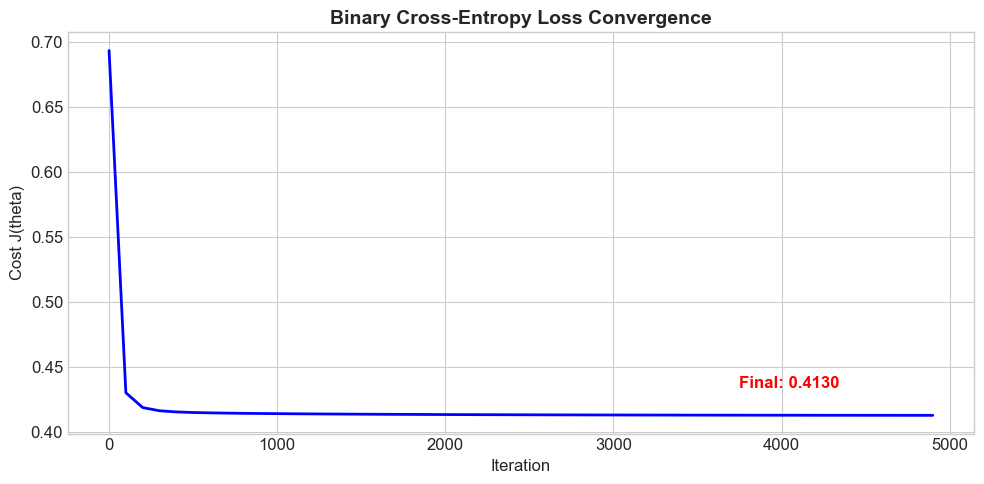

In [14]:
# Cost convergence plot
fig, ax = plt.subplots(figsize=(10, 5))
iterations = range(0, len(model.cost_history) * 100, 100)
ax.plot(iterations, model.cost_history, 'b-', linewidth=2)
ax.set_title('Binary Cross-Entropy Loss Convergence', fontsize=14, fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost J(theta)')
ax.annotate(f'Final: {model.cost_history[-1]:.4f}',
            xy=(len(model.cost_history)*100*0.75, model.cost_history[-1]*1.05),
            fontsize=12, color='red', fontweight='bold')
plt.tight_layout()
plt.savefig('../visualisations/cost_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

observation: Cost decreases monotonically - confirms cross-entropy is convex!

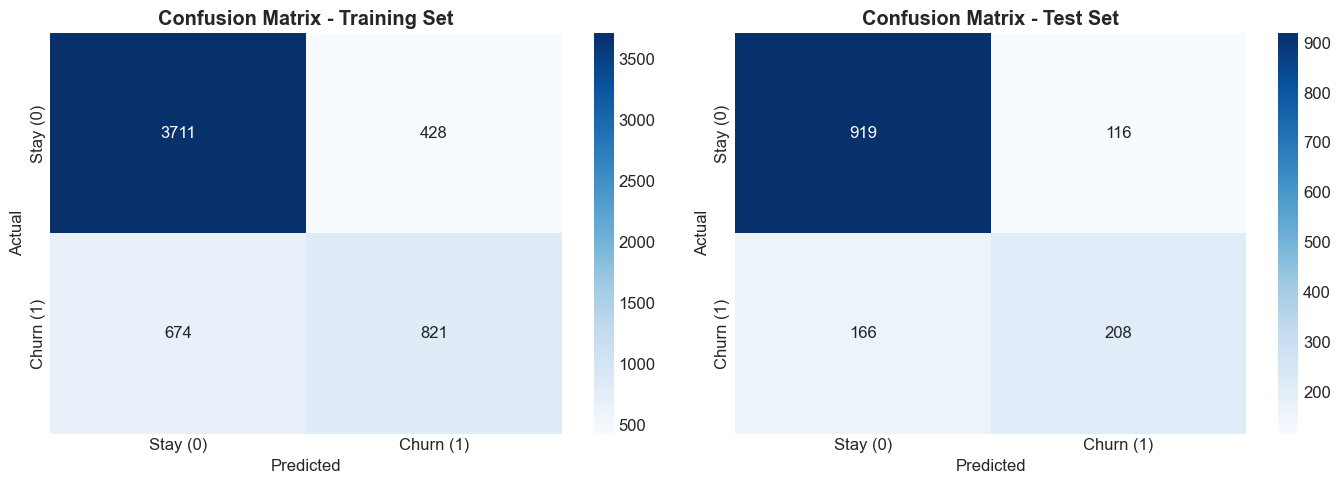

Test Set Confusion Matrix:
  True Negatives  (correctly predicted Stay):   919
  False Positives (false alarm - predicted Churn, actually Stay): 116
  False Negatives (missed Churn - predicted Stay, actually Churn): 166
  True Positives  (correctly predicted Churn):  208

-> Business impact: We missed 166 churning customers (False Negatives).


In [12]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred_labels, title in [
    (axes[0], y_train, y_train_pred, 'Training Set'),
    (axes[1], y_test, y_test_pred, 'Test Set')
]:
    cm = confusion_matrix(y_true, y_pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stay (0)', 'Churn (1)'],
                yticklabels=['Stay (0)', 'Churn (1)'])
    ax.set_title(f'Confusion Matrix - {title}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../visualisations/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

cm_test = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm_test.ravel()
print(f'Test Set Confusion Matrix:')
print(f'  True Negatives  (correctly predicted Stay):   {tn}')
print(f'  False Positives (false alarm - predicted Churn, actually Stay): {fp}')
print(f'  False Negatives (missed Churn - predicted Stay, actually Churn): {fn}')
print(f'  True Positives  (correctly predicted Churn):  {tp}')
print(f'\n-> Business impact: We missed {fn} churning customers (False Negatives).')

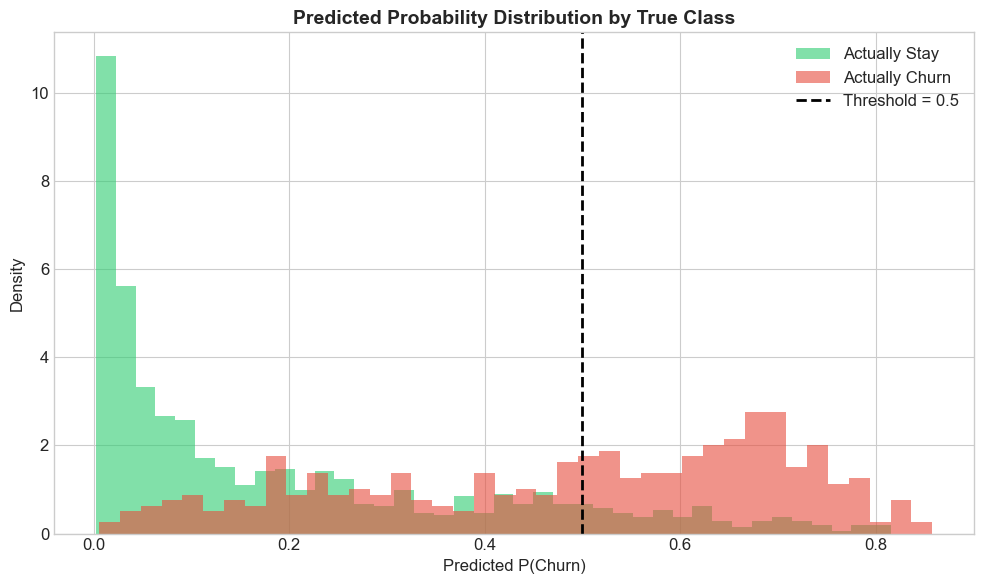

Observations:
  - Good separation between classes -> model learned real patterns
  - Overlap region near 0.3-0.6 -> uncertain predictions
  - Many churn customers have P < 0.5 -> threshold=0.5 may not be optimal


In [15]:
# Predicted probability distributions
fig, ax = plt.subplots(figsize=(10, 6))

probs_stay = y_test_proba[y_test == 0]
probs_churn = y_test_proba[y_test == 1]

ax.hist(probs_stay, bins=40, alpha=0.6, color='#2ecc71', label='Actually Stay', density=True)
ax.hist(probs_churn, bins=40, alpha=0.6, color='#e74c3c', label='Actually Churn', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')
ax.set_title('Predicted Probability Distribution by True Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted P(Churn)')
ax.set_ylabel('Density')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../visualisations/probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observations:')
print('  - Good separation between classes -> model learned real patterns')
print('  - Overlap region near 0.3-0.6 -> uncertain predictions')
print('  - Many churn customers have P < 0.5 -> threshold=0.5 may not be optimal')

In [17]:
# Compare with sklearn
print('='*60)
print('VALIDATION: Scratch vs sklearn')
print('='*60)

# sklearn with similar settings: C = 1/lambda
sklearn_model = SklearnLR(
    C=1/0.01,  # C = 1/lambda_reg
    max_iter=5000,
    solver='lbfgs',
    random_state=42
)
sklearn_model.fit(X_train_scaled, y_train)

y_test_pred_sk = sklearn_model.predict(X_test_scaled)
y_test_proba_sk = sklearn_model.predict_proba(X_test_scaled)[:, 1]

print(f'\n{"Metric":<12} {"Scratch":>10} {"sklearn":>10} {"Match":>8}')
print('-' * 44)

metrics_comparison = [
    ('Accuracy', accuracy_score(y_test, y_test_pred), accuracy_score(y_test, y_test_pred_sk)),
    ('Precision', precision_score(y_test, y_test_pred), precision_score(y_test, y_test_pred_sk)),
    ('Recall', recall_score(y_test, y_test_pred), recall_score(y_test, y_test_pred_sk)),
    ('F1', f1_score(y_test, y_test_pred), f1_score(y_test, y_test_pred_sk)),
]

for name, scratch_val, sk_val in metrics_comparison:
    match = 'YES' if abs(scratch_val - sk_val) < 0.02 else '~'
    print(f'{name:<12} {scratch_val:>10.4f} {sk_val:>10.4f} {match:>8}')


VALIDATION: Scratch vs sklearn

Metric          Scratch    sklearn    Match
--------------------------------------------
Accuracy         0.7999     0.8013      YES
Precision        0.6420     0.6478      YES
Recall           0.5561     0.5508      YES
F1               0.5960     0.5954      YES


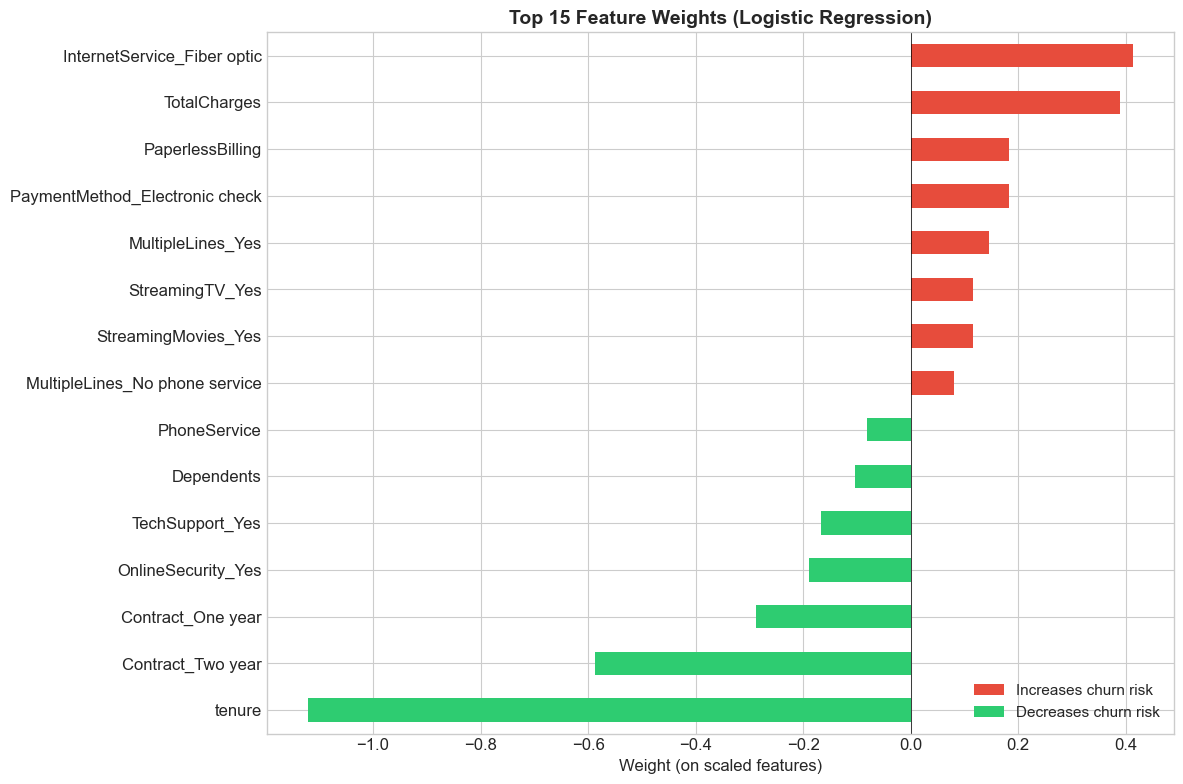

Weight interpretation (on scaled features):
                                    tenure: -1.1212 -> DECREASES churn
                         Contract_Two year: -0.5880 -> DECREASES churn
               InternetService_Fiber optic: +0.4131 -> INCREASES churn
                              TotalCharges: +0.3895 -> INCREASES churn
                         Contract_One year: -0.2878 -> DECREASES churn
                        OnlineSecurity_Yes: -0.1894 -> DECREASES churn
                          PaperlessBilling: +0.1828 -> INCREASES churn
            PaymentMethod_Electronic check: +0.1827 -> INCREASES churn
                           TechSupport_Yes: -0.1664 -> DECREASES churn
                         MultipleLines_Yes: +0.1452 -> INCREASES churn
                           StreamingTV_Yes: +0.1162 -> INCREASES churn
                       StreamingMovies_Yes: +0.1158 -> INCREASES churn
                                Dependents: -0.1039 -> DECREASES churn
                              Pho

In [18]:
# Feature importance (weight magnitude on scaled features)
fig, ax = plt.subplots(figsize=(12, 8))

importance = pd.Series(model.weights, index=feature_cols)
top_abs = importance.abs().nlargest(15)
top_weights = importance[top_abs.index].sort_values()

colors = ['#e74c3c' if w > 0 else '#2ecc71' for w in top_weights]
top_weights.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 15 Feature Weights (Logistic Regression)', fontsize=14, fontweight='bold')
ax.set_xlabel('Weight (on scaled features)')
ax.axvline(x=0, color='black', linewidth=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Increases churn risk'),
                   Patch(facecolor='#2ecc71', label='Decreases churn risk')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('../visualisations/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Weight interpretation (on scaled features):')
for feat in top_abs.index:
    w = importance[feat]
    direction = 'INCREASES churn' if w > 0 else 'DECREASES churn'
    print(f'  {feat:>40s}: {w:+.4f} -> {direction}')